In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from bayesian_dro.Bayesian_DRO_continuous import data_generation, xi_generation, theta_generation
from mis_dro.bayesian_conjugates import normal_gamma_posterior, normal_gamma_rvs
from mis_dro.dataset import data_generation_outliers
from mis_dro.models import ExponentialModel
from mis_dro.npl import Npl

In [8]:
generator = np.random.default_rng(seed=0)
num_observations = 20

data = data_generation(num_observations, random_state=generator)  # generate new observations
lots_of_data = data_generation(10000, random_state=generator)
# data = generator.normal(10, 10, num_observations)
# data = data_generation_outliers(params["num_observations"], contamination, random_state=generator)
# data = expon.rvs(scale=20.0, size=params["num_observations"], random_state=generator)

In [9]:
num_posterior_samples = 100
p = 1  # numbers of unknown parameters

bayes_theta = theta_generation(data, num_posterior_samples, random_state=generator)

alpha_prior = 2.0
beta_prior = 2.0
mu_prior = 0.0
kappa_prior = 1.0
mu_posterior, kappa_posterior, alpha_posterior, beta_posterior = normal_gamma_posterior(data, mu_prior, kappa_prior, alpha_prior, beta_prior)
ng_theta = normal_gamma_rvs(num_posterior_samples, mu_posterior, kappa_posterior, alpha_posterior, beta_posterior, generator=generator)
ng_prior = normal_gamma_rvs(num_posterior_samples, mu_prior, kappa_prior, alpha_prior, beta_prior, generator=generator)
alpha_posterior, beta_posterior
wll_model = ExponentialModel(num_observations)
wll_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    wll_model,
    l=-1.0,
    loss_fn="wll",
)
wll_npl.draw_samples(random_state=generator)
wll_theta = wll_npl.sample

mmd_model = ExponentialModel(num_observations)
mmd_npl = Npl(
    data.reshape((num_observations, 1)),
    num_posterior_samples,
    p,
    num_observations,
    mmd_model,
    l=-1.0,
    loss_fn="mmd",
)
mmd_npl.draw_samples(random_state=generator)
mmd_theta = mmd_npl.sample

In [23]:
num_likelihood_samples = 100
bayes_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
wll_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
mmd_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
ng_xi = np.zeros([num_posterior_samples, num_likelihood_samples])
for i in range(num_posterior_samples):
    bayes_xi[i] = xi_generation(bayes_theta[i], num_likelihood_samples, random_state=generator)
    wll_xi[i] = xi_generation(wll_theta[i], num_likelihood_samples, random_state=generator)
    mmd_xi[i] = xi_generation(mmd_theta[i], num_likelihood_samples, random_state=generator)
    ng_xi[i] = generator.normal(ng_theta[i,0], np.sqrt(1.0 / ng_theta[i,1]), size=num_likelihood_samples)

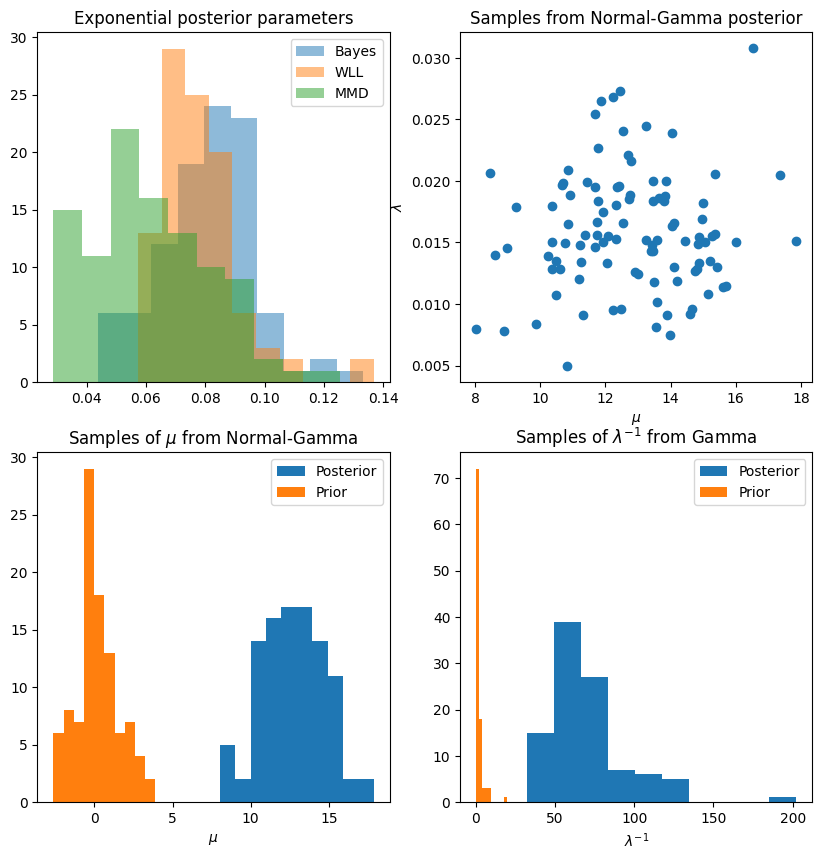

In [24]:
# plot the posterior
n_posterior_bins = int(num_posterior_samples / 10)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax1.hist(bayes_theta, alpha=0.5, label="Bayes", bins=n_posterior_bins)
ax1.hist(wll_theta, alpha=0.5, label="WLL", bins=n_posterior_bins)
ax1.hist(mmd_theta, alpha=0.5, label="MMD", bins=n_posterior_bins)
ax1.legend()
ax1.set_title("Exponential posterior parameters")

# normal-gamma gets its own plot: is tricky to visualise because its a 2D posterior over both mean and precision
ax2.scatter(ng_theta[:,0], ng_theta[:,1])
ax2.set_xlabel("$\mu$")
ax2.set_ylabel("$\lambda$")
ax2.set_title("Samples from Normal-Gamma posterior")

ax3.hist(ng_theta[:,0], bins=n_posterior_bins, label="Posterior")
ax3.hist(ng_prior[:,0], bins=n_posterior_bins, label="Prior")
ax3.set_title("Samples of $\mu$ from Normal-Gamma")
ax3.set_xlabel("$\mu$")
ax3.legend()

ax4.hist(1/ng_theta[:,1], bins=n_posterior_bins, label="Posterior")
ax4.hist(1/ng_prior[:,1], bins=n_posterior_bins, label="Prior")
ax4.set_title("Samples of $\lambda^{-1}$ from Gamma")
ax4.set_xlabel("$\lambda^{-1}$")
ax4.legend()
fig.show()

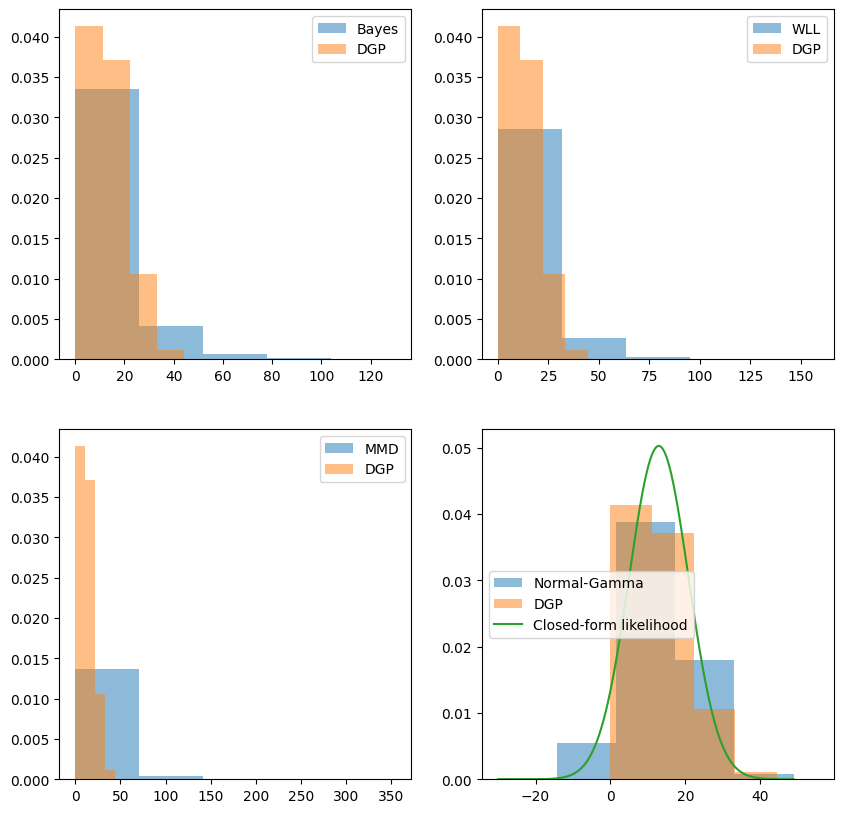

In [25]:
# plot the likelihood
fig, ((ax1, ax2), (ax3, ax4))= plt.subplots(ncols=2, nrows=2, figsize=(10,10))
nbins = int(num_likelihood_samples / 10)
ax1.hist(bayes_xi.flatten(), alpha=0.5, label="Bayes", bins=nbins, density=True)
ax2.hist(wll_xi.flatten(), alpha=0.5, label="WLL", bins=nbins, density=True)
ax3.hist(mmd_xi.flatten(), alpha=0.5, label="MMD", bins=nbins, density=True)
ax4.hist(ng_xi.flatten(), alpha=0.5, label="Normal-Gamma", bins=nbins, density=True)

# NOTE remember to change the source of lots_of_data too!
ax1.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax2.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax3.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
ax4.hist(lots_of_data, alpha=0.5, label="DGP", bins=nbins, density=True)
x_values = np.arange(np.min(ng_xi.flatten()), np.max(ng_xi.flatten()), 0.001)
y_values = sp.stats.norm.pdf(x_values, mu_posterior, np.sqrt(beta_posterior / alpha_posterior))
ax4.plot(x_values, y_values, label="Closed-form likelihood")

ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()

# ax.set_xlim(-50, 50)
fig.show()